<a href="https://colab.research.google.com/github/Fushionek/MLTraining/blob/main/FreeCodeCamp/freeCodeCamp_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [74]:
medical_charges_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'
from urllib.request import urlretrieve
urlretrieve(medical_charges_url, 'medical.csv')
import pandas as pd
medical_df = pd.read_csv('medical.csv')
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [75]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [76]:
medical_df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [77]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [78]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10,6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [79]:
medical_df.age.describe()

,age
count,1338.000000
mean,39.207025
std,14.049960
min,18.000000
25%,27.000000
50%,39.000000
75%,51.000000
max,64.000000


In [80]:
fig = px.histogram(medical_df,x='age',marginal='box',nbins=47,title ='Distribution of age')
fig.update_layout(bargap=0.1)
fig.show()

In [81]:
fig = px.histogram(medical_df,x='bmi',marginal='box',color_discrete_sequence=['red'],title ='Distribution of BMI')
fig.update_layout(bargap=0.1)
fig.show()

In [82]:
fig = px.histogram(medical_df,x='charges',marginal='box',color='smoker',color_discrete_sequence=['green','grey'],title ='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

In [83]:
medical_df.smoker.value_counts()

,count
smoker,
no,1064
yes,274


In [84]:
px.histogram(medical_df, x='smoker', color='sex',title='Smoker')

In [85]:
fig = px.scatter(medical_df,x='age',y='charges',color='smoker',opacity=0.8,hover_data=['sex'],title='Age / Charges')
fig.update_traces(marker_size=5)
fig.show()

In [86]:
fig = px.scatter(medical_df,x='bmi',y='charges',color='smoker',opacity=0.8,hover_data=['sex'],title='BMI / Charges')
fig.update_traces(marker_size=5)
fig.show()

In [87]:
px.violin(medical_df,x='children',y='charges')

In [88]:
medical_df.charges.corr(medical_df.age)

np.float64(0.2990081933306476)

In [89]:
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362895)

In [90]:
medical_df.charges.corr(medical_df.children)

np.float64(0.06799822684790478)

In [91]:
smoker_values = {'no': 0,'yes' : 1}
smoker_numeric = medical_df.smoker.map(smoker_values)
smoker_numeric

,smoker
0,1
1,0
2,0
3,0
4,0
...,...
1333,0
1334,0
1335,0
1336,0


In [92]:
medical_df.charges.corr(smoker_numeric)

np.float64(0.787251430498478)

In [93]:
medical_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

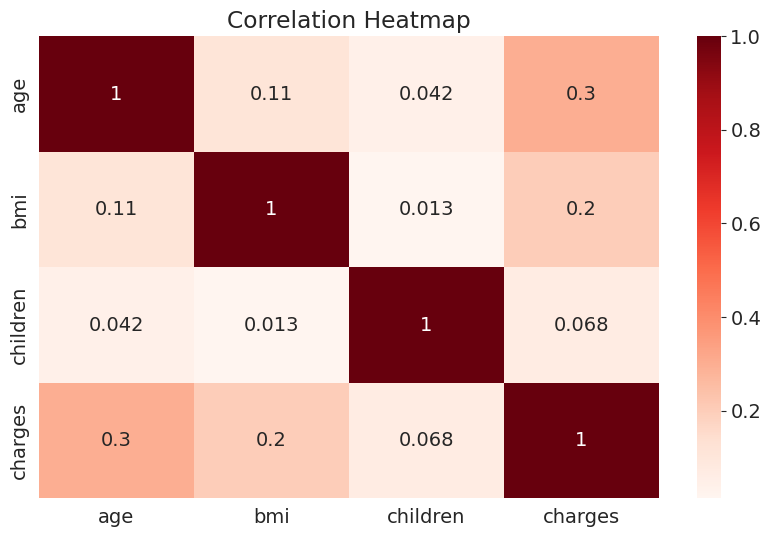

In [94]:
sns.heatmap(medical_df.corr(numeric_only=True), cmap='Reds', annot=True)
plt.title('Correlation Heatmap')

In [95]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

<Axes: title={'center': 'Age / Charges'}, xlabel='age', ylabel='charges'>

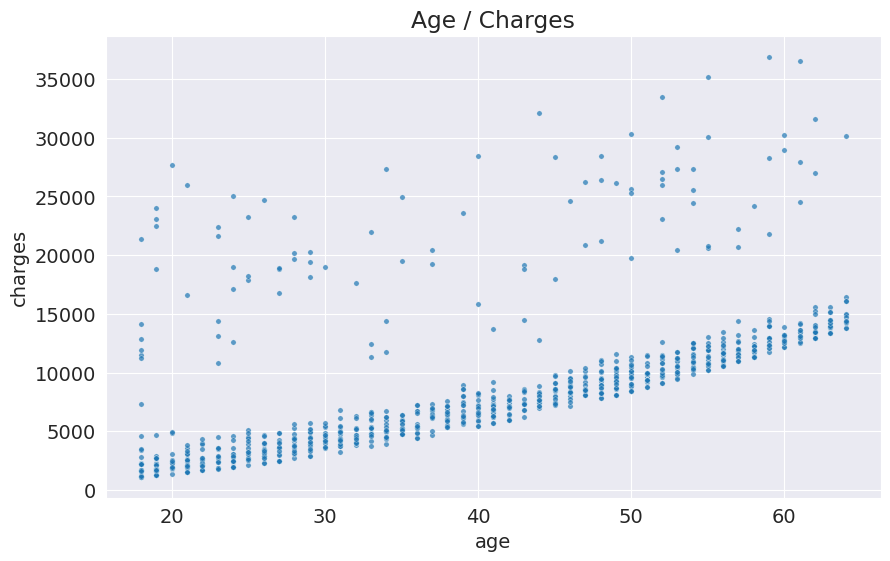

In [96]:
plt.title('Age / Charges')
sns.scatterplot(data=non_smoker_df, x='age', y='charges', alpha=0.7,s=15)

In [97]:
def estimate_charges(age, w, b):
  return w * age + b

In [98]:
w, b = 50, 100

In [99]:
estimate_charges(30,w,b)

1600

In [100]:
ages = non_smoker_df.age
ages

,age
1,18
2,28
3,33
4,32
5,31
...,...
1332,52
1333,50
1334,18
1335,18


In [101]:
estimate_charges = estimate_charges(ages,w,b)

In [102]:
estimate_charges

,age
1,1000
2,1500
3,1750
4,1700
5,1650
...,...
1332,2700
1333,2600
1334,1000
1335,1000


In [103]:
non_smoker_df.charges

,charges
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
5,3756.62160
...,...
1332,11411.68500
1333,10600.54830
1334,2205.98080
1335,1629.83350


Text(0, 0.5, 'Estimated Charge')

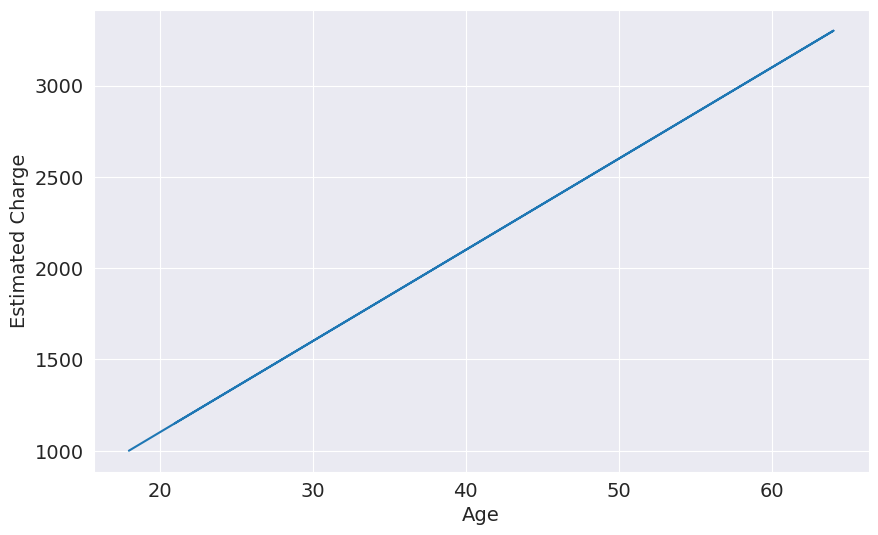

In [104]:
plt.plot(ages, estimate_charges)
plt.xlabel('Age')
plt.ylabel('Estimated Charge')

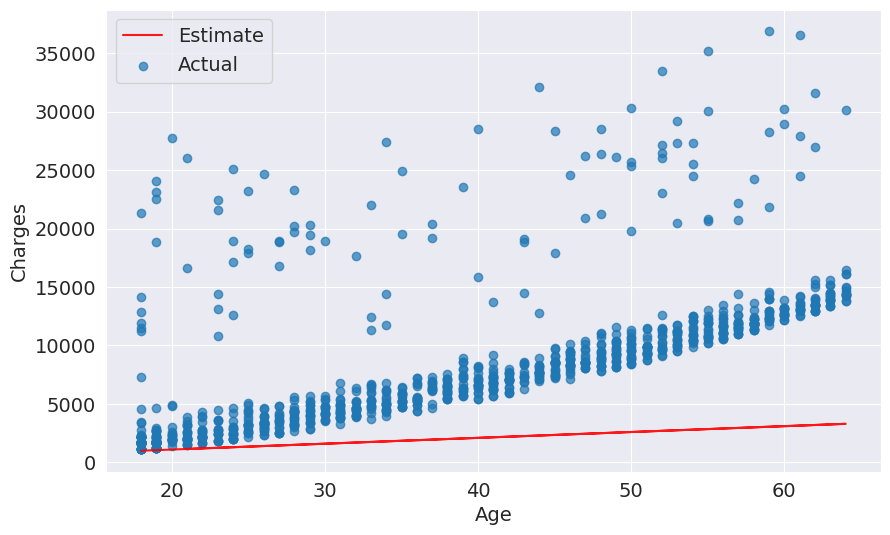

In [105]:
target = non_smoker_df.charges

plt.plot(ages, estimate_charges, 'r', alpha=0.9)
plt.scatter(ages, target, alpha=0.7)
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend(['Estimate','Actual'])

In [106]:
def try_param(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges

    predictions = estimate_charges(ages, w, b)

    plt.plot(ages, predictions, 'r', alpha=0.9)
    plt.scatter(ages, target, alpha=0.7)
    plt.xlabel('Age')
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual'])

In [107]:
try_param(400,5000)

TypeError: 'Series' object is not callable

In [112]:
targets = non_smoker_df.charges

In [111]:
targets

NameError: name 'targets' is not defined

In [110]:
predictions = estimate_charges

In [109]:
predictions

NameError: name 'predictions' is not defined

In [108]:
import numpy as np
def rmse(targets, predictions):
  return np.sqrt(np.mean(np.square(targets - predictions)))

In [113]:
w,b = 50,100

In [114]:
def calculate_predictions(age, w, b):
    return w * age + b

w, b = 50, 100

targets = non_smoker_df['charges']
prediction = calculate_predictions(non_smoker_df.age, w, b)

print("RMSE:", rmse(targets, prediction))

RMSE: 8461.949562575493


In [115]:
def try_param(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges

    predictions = calculate_predictions(ages, w, b)

    plt.plot(ages, predictions, 'r', alpha=0.9)
    plt.scatter(ages, target, alpha=0.8)
    plt.xlabel('Age')
    plt.ylabel('Charges')
    plt.legend(['Prediction', 'Actual'])
    loss = rmse(targets,predictions)
    print('RMSE loss: ', loss)

RMSE loss:  8461.949562575493


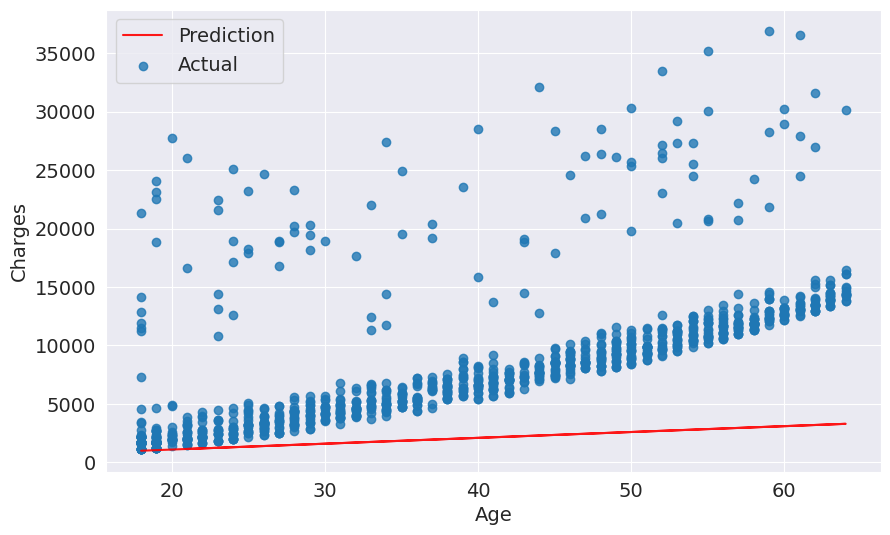

In [116]:
try_param(50,100)

RMSE loss:  4991.993804156943


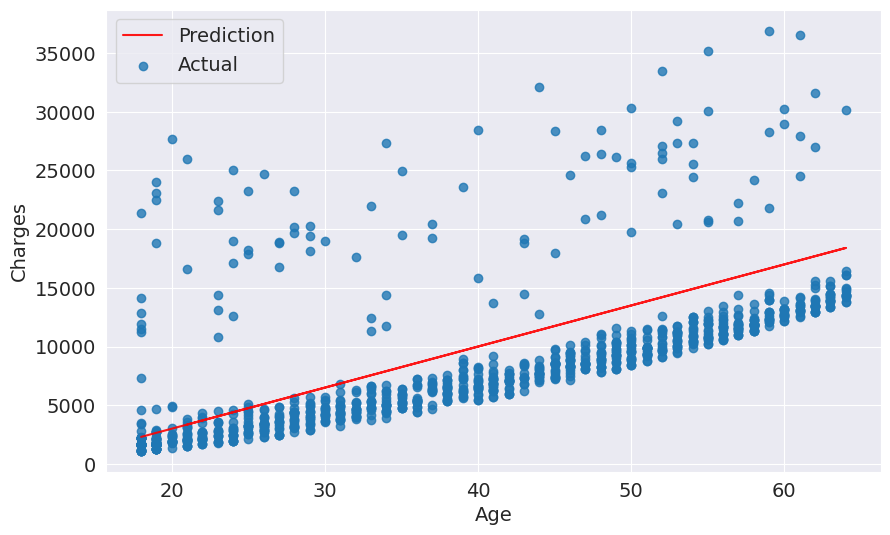

In [117]:
try_param(350,-4000)

In [118]:
from sklearn.linear_model import LinearRegression

In [119]:
model = LinearRegression()

In [120]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.



In [121]:
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges
print('Inputs: ', inputs.shape)
print('Targets: ', targets.shape)

Inputs:  (1064, 1)
Targets:  (1064,)


In [122]:
model.fit(inputs,targets)

LinearRegression()

In [123]:
model.predict(np.array([[23],
                        [37],
                        [61]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [124]:
predictions = model.predict(inputs)
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [125]:
rmse(target, predictions)

np.float64(4662.505766636395)

In [126]:
model.coef_
#w

array([267.24891283])

In [127]:
#b
model.intercept_

np.float64(-2091.4205565650864)

RMSE loss:  4662.505766636395


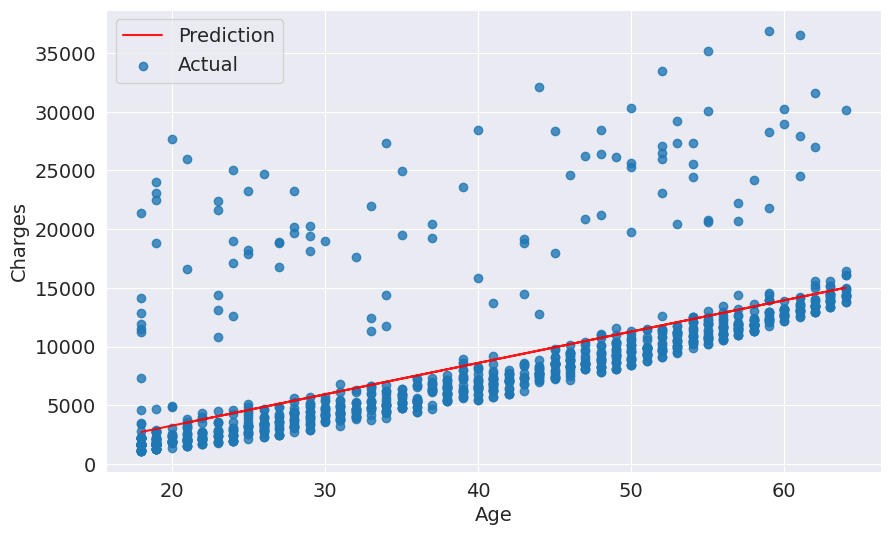

In [128]:
try_param(model.coef_,model.intercept_)

In [129]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
inputs_scaled = scaler.fit_transform(inputs)


sgd_model = SGDRegressor(max_iter=1000, tol=1e-3, eta0=0.01, random_state=42)

sgd_model.fit(inputs_scaled, targets)

predictions_sgd = sgd_model.predict(inputs_scaled)

print("SGD RMSE:", rmse(targets, predictions_sgd))

SGD RMSE: 4662.578503411452


In [130]:
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [131]:
from sklearn.linear_model import LinearRegression

smoker_df = medical_df[medical_df.smoker == 'yes']

inputs = smoker_df[['age']]
targets = smoker_df['charges']

model = LinearRegression()

model.fit(inputs, targets)

predictions = model.predict(inputs)

print("Smoker RMSE:", rmse(targets, predictions))

Smoker RMSE: 10711.00334810241


In [132]:
from sklearn.linear_model import LinearRegression

non_smoker_df = medical_df[medical_df.smoker == 'no']

i , t = non_smoker_df[['age']], non_smoker_df[['charges']]


model = LinearRegression().fit(i, t)
pred = model.predict(i)

loss = rmse(t, pred)
print('Loss: ', loss)

Loss:  4662.505766636395


In [133]:
non_smoker_df.charges.corr(non_smoker_df.bmi)

np.float64(0.0840365431283327)

In [134]:
fig = px.scatter(non_smoker_df, x='bmi', y='charges')


In [135]:
fig.show()

In [136]:
model.coef_ , model.intercept_

(array([[267.24891283]]), array([-2091.42055657]))

In [137]:
non_smoker_df.charges.corr(non_smoker_df.children)

np.float64(0.13892870453542192)

In [141]:
fig = px.strip(non_smoker_df, x='children',y='charges')

In [142]:
fig.show()

In [143]:
i,t = non_smoker_df[['age','bmi','children']], non_smoker_df[['charges']]

model = LinearRegression().fit(i,t)

pred = model.predict(i)

loss = rmse(t,pred)
print('Loss: ',loss)

Loss:  4608.470405038247


In [144]:
i,t = smoker_df[['age','bmi','children']], smoker_df[['charges']]

model = LinearRegression().fit(i,t)

pred = model.predict(i)

loss = rmse(t,pred)
print('Loss: ',loss)

Loss:  5718.202480524154


In [145]:
i,t = medical_df[['age','bmi','children']], medical_df['charges']

model = LinearRegression().fit(i,t)

pred = model.predict(i)

loss = rmse(t,pred)

print('Loss: ',loss)

Loss:  11355.317901125973


In [146]:
px.scatter(medical_df, x='age',y='charges', color='smoker')

<Axes: xlabel='smoker', ylabel='charges'>

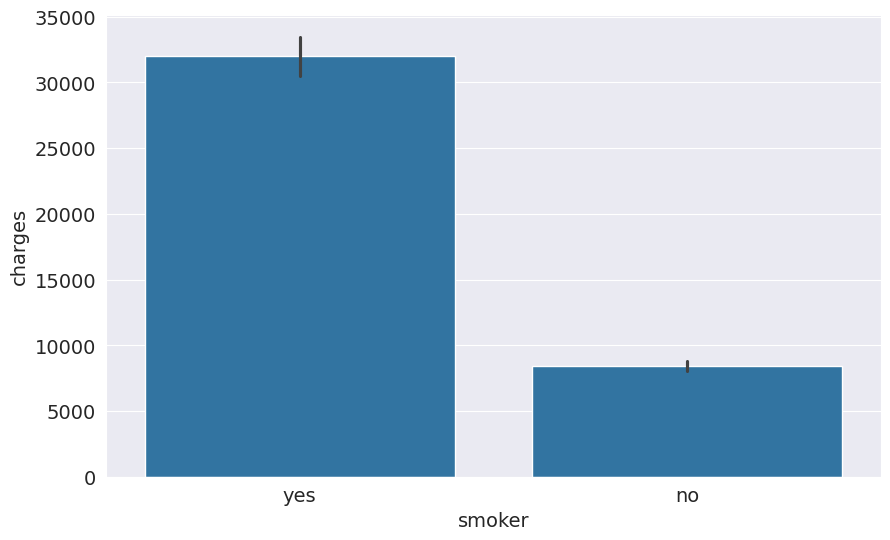

In [151]:
sns.barplot(data=medical_df, x='smoker',y='charges')

In [152]:
smoker_code = {'yes': 1, 'no' : 0}

In [153]:
medical_df['smoker_code'] = medical_df.smoker.map(smoker_code)

In [154]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


In [155]:
medical_df.charges.corr(medical_df.smoker_code)

np.float64(0.787251430498478)

In [157]:
i,t = medical_df[['age','bmi','children','smoker_code']], medical_df[['charges']]
model = LinearRegression().fit(i,t)

pred = model.predict(i)

loss = rmse(t,pred)

print('Loss: ',loss)

Loss:  6056.439217188081


In [162]:
sex_codes = {'female': 0,'male' : 1}

In [165]:
medical_df['sex_code'] = medical_df.sex.map(sex_codes)

In [166]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,1
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1
1334,18,female,31.920,0,no,northeast,2205.98080,0,0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0


In [167]:
medical_df.charges.corr(medical_df.sex_code)

np.float64(0.057292062202025484)

In [169]:
i,t = medical_df[['age','bmi','children','smoker_code','sex_code']], medical_df[['charges']]
model = LinearRegression().fit(i,t)

pred = model.predict(i)

loss = rmse(t,pred)

print('Loss: ',loss)

Loss:  6056.100708754546


<Axes: xlabel='region', ylabel='charges'>

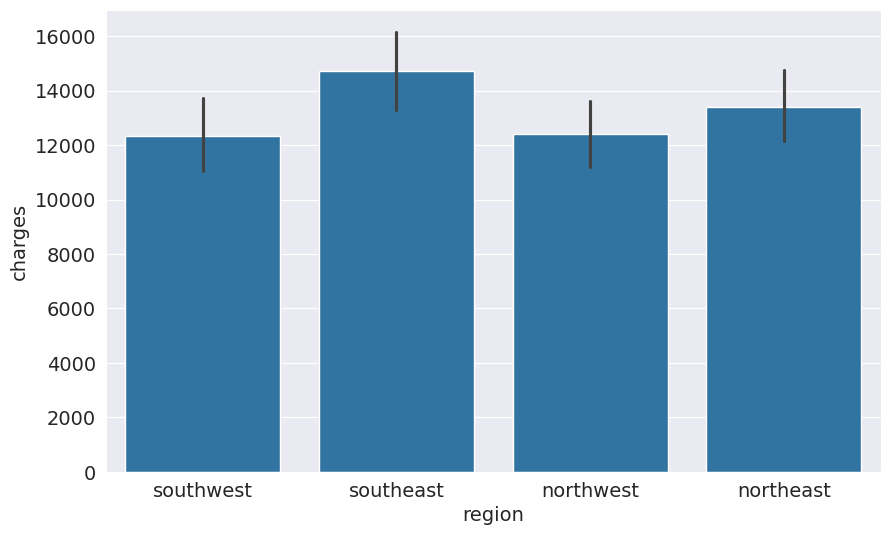

In [170]:
sns.barplot(data=medical_df,x='region',y='charges')

In [171]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()
enc.fit(medical_df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [172]:
one_hot = enc.transform(medical_df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

In [173]:
medical_df[['northeast','northwest','southeast','southwest']] = one_hot

In [174]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [175]:
input_col = ['age','bmi','children','smoker_code','sex_code','northeast','northwest','southeast','southwest']
i,t = medical_df[input_col], medical_df['charges']
model = LinearRegression().fit(i,t)

pred = model.predict(i)

loss = rmse(t,pred)

print('Loss: ',loss)


Loss:  6041.6796511744515


In [176]:
model.coef_

array([  256.85635254,   339.19345361,   475.50054515, 23848.53454191,
        -131.3143594 ,   587.00923503,   234.0453356 ,  -448.01281436,
        -373.04175627])

In [177]:
model.intercept_

np.float64(-12525.547811195444)

In [179]:
model.predict([[28,30,2,1,0,0,1,0,0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([29875.81463599])

In [180]:
from sklearn.preprocessing import StandardScaler

In [183]:
num_col = ['age','bmi','children']
scaler = StandardScaler()
scaler.fit(medical_df[num_col])

StandardScaler()

In [184]:
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [185]:
scaler.var_

array([197.25385199,  37.16008997,   1.45212664])

In [186]:
scaled = scaler.transform(medical_df[num_col])
scaled

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]])

In [187]:
cat_cols = ['smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
categorical_data = medical_df[cat_cols].values

In [189]:
inputs = np.concatenate((scaled, categorical_data), axis=1)
targets = medical_df.charges

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6041.6796511744515


In [191]:
weights_df = pd.DataFrame({
    'feature': np.append(num_col + cat_cols, 1),
    'weight': np.append(model.coef_, model.intercept_)
})
weights_df.sort_values('weight', ascending=False)

,feature,weight
3,smoker_code,23848.534542
9,1,8466.483215
0,age,3607.472736
1,bmi,2067.691966
5,northeast,587.009235
2,children,572.998210
6,northwest,234.045336
4,sex_code,-131.314359
8,southwest,-373.041756
7,southeast,-448.012814


In [192]:
new_customers = [[28,30,2,1,0,0,1,0,0]]

In [201]:
scaler.transform([[28,30,2]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



array([[-0.79795355, -0.10882659,  0.75107928]])

In [202]:
model.predict([[-0.79795355, -0.10882659,  0.75107928,1,0,0,1,0,0]])

array([29875.81463371])